<a href="https://colab.research.google.com/github/shirshmohan/Kidney-Stone-Classfication-Project/blob/main/EAnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from shutil import copyfile
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras import layers, models, optimizers
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import os

# Correcting the base_path as it appears to have a redundant directory segment
base_path = '/content/drive/MyDrive/MinorProject/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone'
categories = ["Cyst", "Normal", "Stone", "Tumor"]

image_paths = []
labels = []

for category in categories:
    category_path = os.path.join(base_path, category)
    for image_name in os.listdir(category_path):
        image_path = os.path.join(category_path, image_name)
        image_paths.append(image_path)
        labels.append(category)

df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

In [ ]:
df.shape

(12449, 2)

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df['category_encoded'] = label_encoder.fit_transform(df['label'])

df = df[['image_path', 'category_encoded']]

In [ ]:
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    train_size=0.8,
    shuffle=True,
    random_state=42,
    stratify=df['category_encoded']
)


valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    shuffle=True,
    random_state=42,
    stratify=temp_df['category_encoded']
)

ros = RandomOverSampler(random_state=42)


X_train_resampled, y_train_resampled = ros.fit_resample(
    train_df[['image_path']],
    train_df['category_encoded']
)

In [ ]:
train_df_balanced = pd.DataFrame(X_train_resampled, columns=['image_path'])
train_df_balanced['category_encoded'] = y_train_resampled

print("Balanced Training Set Counts:\n", train_df_balanced['category_encoded'].value_counts())
print("\nOriginal (Imbalanced) Test Set Counts:\n", test_df['category_encoded'].value_counts())

Balanced Training Set Counts:
 category_encoded
1    4063
0    4063
2    4063
3    4063
Name: count, dtype: int64

Original (Imbalanced) Test Set Counts:
 category_encoded
1    508
0    371
3    228
2    138
Name: count, dtype: int64


In [ ]:
train_df_balanced['category_encoded'] = train_df_balanced['category_encoded'].astype(str)
test_df['category_encoded'] = test_df['category_encoded'].astype(str)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers


def efficient_attention_block(x, reduction_ratio=8):
    channels = x.shape[-1]

    avg_pool = layers.GlobalAveragePooling2D()(x)
    dense1 = layers.Dense(channels // reduction_ratio, activation="relu")(avg_pool)
    dense2 = layers.Dense(channels, activation="sigmoid")(dense1)

    scale = layers.Multiply()([x, layers.Reshape((1, 1, channels))(dense2)])
    return scale



def build_eanet(input_shape=(224, 224, 3), num_classes=4):

    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(64, (3, 3), strides=2, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)


    for _ in range(2):
        residual = x
        x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = efficient_attention_block(x)

        residual = layers.Conv2D(128, (1, 1), padding="same")(residual)
        x = layers.Add()([x, residual])


    for _ in range(2):
        residual = x
        x = layers.Conv2D(256, (3, 3), padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = efficient_attention_block(x)

        residual = layers.Conv2D(256, (1, 1), padding="same")(residual)
        x = layers.Add()([x, residual])


    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs)
    return model



model = build_eanet(input_shape=(224, 224, 3), num_classes=len(categories))

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 112, 112,  │      1,792 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_9[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 56, 56,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        512 │ conv2d_10[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 16)        │      2,064 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 128)       │      2,176 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_4 (Reshape) │ (None, 1, 1, 128) │          0 │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_4          │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (Multiply)          │ 128)              │            │ reshape_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 56, 56,    │      8,320 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 56, 56,    │          0 │ multiply_4[0][0], │
│                     │ 128)              │            │ conv2d_11[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 56, 56,    │    147,584 │ add_4[0][0]       │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        512 │ conv2d_12[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 16)        │      2,064 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 128)       │      2,176 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,410,916 (5.38 MB)

 Trainable params: 1,409,252 (5.38 MB)

 Non-trainable params: 1,664 (6.50 KB)

In [ ]:
batch_size = 16
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)

tr_gen = ImageDataGenerator(rescale=1./255)
ts_gen = ImageDataGenerator(rescale=1./255)

train_gen_new = tr_gen.flow_from_dataframe(
    train_df_balanced,
    x_col='image_path',
    y_col='category_encoded',
    target_size=img_size,
    class_mode='sparse',
    color_mode='rgb',
    shuffle=True,
    batch_size=batch_size
)

Found 16252 validated image filenames belonging to 4 classes.


In [ ]:
train_df_balanced['category_encoded'] = train_df_balanced['category_encoded'].astype(str)
valid_df['category_encoded'] = valid_df['category_encoded'].astype(str)
test_df['category_encoded'] = test_df['category_encoded'].astype(str)

In [ ]:
valid_gen_new = ts_gen.flow_from_dataframe(
    valid_df,
    x_col='image_path',
    y_col='category_encoded',
    target_size=img_size,
    class_mode='sparse',
    color_mode='rgb',
    shuffle=True,
    batch_size=batch_size
)

test_gen_new = ts_gen.flow_from_dataframe(
    test_df,
    x_col='image_path',
    y_col='category_encoded',
    target_size=img_size,
    class_mode='sparse',
    color_mode='rgb',
    shuffle=False,
    batch_size=batch_size
)

Found 1245 validated image filenames belonging to 4 classes.
Found 1245 validated image filenames belonging to 4 classes.


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [ ]:
epochs=5

checkpoint = ModelCheckpoint(
    'best_eanet_model.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)
history = model.fit(
  train_gen_new,
  validation_data=valid_gen_new,
  epochs=epochs
)

Epoch 1/5
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6503 - loss: 0.8279

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1016/1016 ━━━━━━━━━━━━━━━━━━━━ 4289s 4s/step - accuracy: 0.6504 - loss: 0.8277 - val_accuracy: 0.6723 - val_loss: 0.8741
Epoch 2/5
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 127s 125ms/step - accuracy: 0.9067 - loss: 0.2619 - val_accuracy: 0.6169 - val_loss: 1.3048
Epoch 3/5
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 129s 127ms/step - accuracy: 0.9608 - loss: 0.1139 - val_accuracy: 0.9631 - val_loss: 0.0876
Epoch 4/5
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 126s 124ms/step - accuracy: 0.9814 - loss: 0.0578 - val_accuracy: 0.9173 - val_loss: 0.2193
Epoch 5/5
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 125s 123ms/step - accuracy: 0.9835 - loss: 0.0534 - val_accuracy: 0.9783 - val_loss: 0.0560


In [ ]:
import shutil
model.save('best_eanet_model.keras')

shutil.copy('best_eanet_model.keras', '/content/drive/MyDrive/eanet_model')

'/content/drive/MyDrive/eanet_model'

In [ ]:
test_labels = test_gen_new.classes
predictions = model.predict(test_gen_new)
predicted_classes = np.argmax(predictions, axis=1)

78/78 ━━━━━━━━━━━━━━━━━━━━ 490s 6s/step


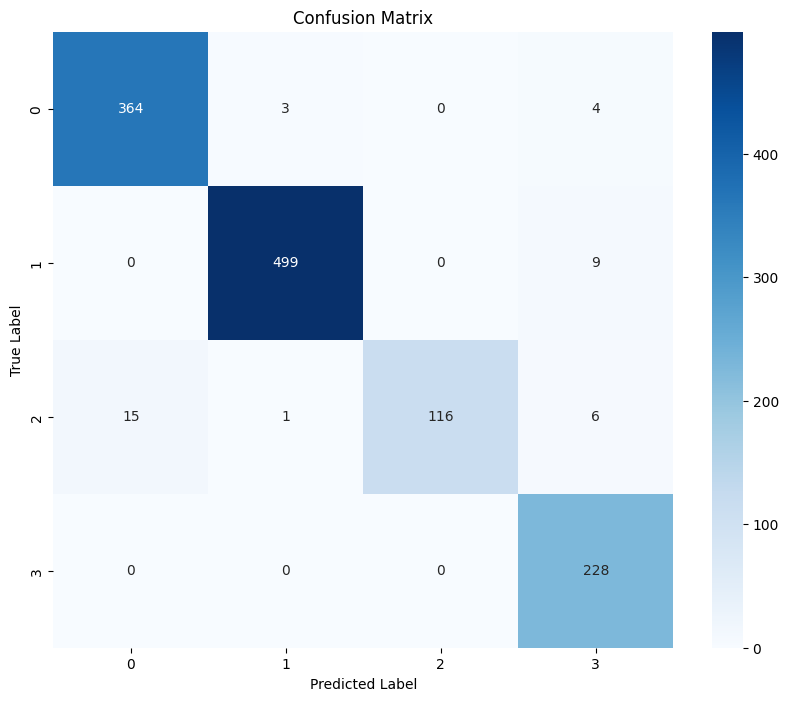

In [ ]:
import seaborn as sns
conf_matrix = confusion_matrix(test_labels, predicted_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=list(test_gen_new.class_indices.keys()), yticklabels=list(test_gen_new.class_indices.keys()))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

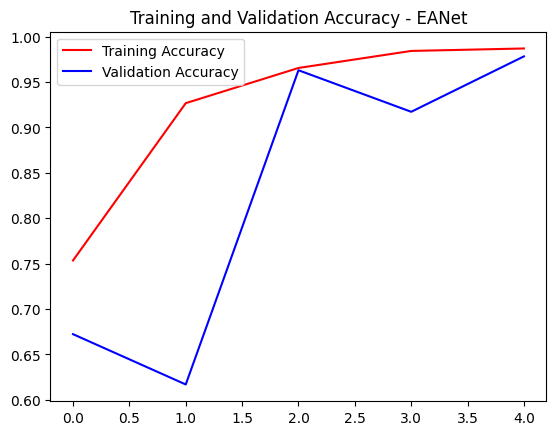

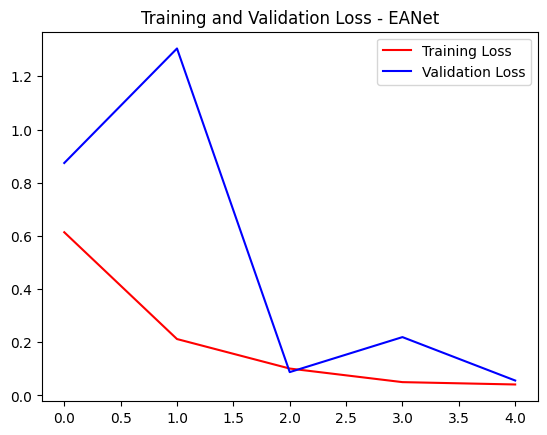

In [ ]:
epochs_range = range(len(history.history['accuracy']))

plt.plot(epochs_range, history.history['accuracy'], 'r', label='Training Accuracy')
plt.plot(epochs_range, history.history['val_accuracy'], 'b', label='Validation Accuracy')
plt.title('Training and Validation Accuracy - EANet')
plt.legend()
plt.show()

plt.plot(epochs_range, history.history['loss'], 'r', label='Training Loss')
plt.plot(epochs_range, history.history['val_loss'], 'b', label='Validation Loss')
plt.title('Training and Validation Loss - EANet')
plt.legend()
plt.show()